In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install -q datasets PyYAML scikit-learn

In [3]:
from pathlib import Path

import torch


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1"
)

REPO_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1-repo"
)

TASK2_WORK_ROOT = (
    PROJECT_ROOT / "task2"
)

TASK3_WORK_ROOT = (
    PROJECT_ROOT / "task3"
)

TASK3_REPO_ROOT = (
    REPO_ROOT / "task3"
)

PACS_ROOT = (
    PROJECT_ROOT / "datasets/PACS"
)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

if DEVICE.type != "cuda":
    raise RuntimeError(
        "Change the Colab runtime to GPU."
    )

print(
    "GPU:",
    torch.cuda.get_device_name(0),
)

Device: cuda
GPU: Tesla T4


In [4]:
%cd /content/drive/MyDrive/ATML/PA1-repo

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F

from datasets import load_from_disk

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

from torch.utils.data import DataLoader

from tqdm.auto import tqdm

from common.seed import set_seed

from shared.pacs import (
    PACSLabeledDataset,
    build_pacs_evaluation_transform,
)

from shared.pacs_protocol import (
    load_pacs_protocol,
)

from task2.models.classifier_head import (
    PACSClassifier,
)


SEED = 6304

set_seed(SEED)

print("Seed:", SEED)

/content/drive/MyDrive/ATML/PA1-repo
Seed: 6304


In [5]:
pacs_dataset = load_from_disk(
    str(PACS_ROOT)
)

PACS_SPLIT_PATH = (
    REPO_ROOT
    / "shared/splits/"
    "pacs_sketch_seed6304.json"
)

pacs_protocol = load_pacs_protocol(
    PACS_SPLIT_PATH
)

target_domain = pacs_protocol[
    "target_domain"
]

target_indices = pacs_protocol[
    "target_adaptation_indices"
]

target_dataset = PACSLabeledDataset(
    dataset=pacs_dataset,
    indices=target_indices,
    transform=(
        build_pacs_evaluation_transform()
    ),
    domain_name=target_domain,
)

target_loader = DataLoader(
    target_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

class_names = pacs_protocol[
    "class_names"
]

print(
    "Final target domain:",
    target_domain,
)

print(
    "Target samples:",
    len(target_dataset),
)

print(
    "Class names:",
    class_names,
)

print(
    "Target labels now available:",
    "label" in target_dataset[0],
)

Final target domain: sketch
Target samples: 3929
Class names: ['dog', 'elephant', 'giraffe', 'guitar', 'horse', 'house', 'person']
Target labels now available: True


In [6]:
CHECKPOINT_PATHS = {
    "erm": (
        TASK2_WORK_ROOT
        / "checkpoints/source_only_best.pt"
    ),
    "dan_dg": (
        TASK3_WORK_ROOT
        / "checkpoints/dan_dg_best.pt"
    ),
    "sam": (
        TASK3_WORK_ROOT
        / "checkpoints/sam_best.pt"
    ),
    "dan_dg_lambda_0p1": (
        TASK3_WORK_ROOT
        / "checkpoints/"
        "dan_dg_lambda_0p1_best.pt"
    ),
    "dan_dg_lambda_10p0": (
        TASK3_WORK_ROOT
        / "checkpoints/"
        "dan_dg_lambda_10p0_best.pt"
    ),
}

for method_name, checkpoint_path in (
    CHECKPOINT_PATHS.items()
):
    print(
        method_name,
        "| exists:",
        checkpoint_path.exists(),
        "|",
        checkpoint_path,
    )

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            checkpoint_path
        )

erm | exists: True | /content/drive/MyDrive/ATML/PA1/task2/checkpoints/source_only_best.pt
dan_dg | exists: True | /content/drive/MyDrive/ATML/PA1/task3/checkpoints/dan_dg_best.pt
sam | exists: True | /content/drive/MyDrive/ATML/PA1/task3/checkpoints/sam_best.pt
dan_dg_lambda_0p1 | exists: True | /content/drive/MyDrive/ATML/PA1/task3/checkpoints/dan_dg_lambda_0p1_best.pt
dan_dg_lambda_10p0 | exists: True | /content/drive/MyDrive/ATML/PA1/task3/checkpoints/dan_dg_lambda_10p0_best.pt


In [7]:
models = {}
checkpoint_information = {}

for method_name, checkpoint_path in (
    CHECKPOINT_PATHS.items()
):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )

    model = PACSClassifier(
        number_of_classes=7
    ).to(DEVICE)

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    model.eval()

    models[method_name] = model

    checkpoint_information[
        method_name
    ] = {
        "selected_epoch": int(
            checkpoint["epoch"]
        ),
        "source_selection_macro_f1": float(
            checkpoint[
                "selection_score"
            ]
        ),
    }

    print(
        method_name,
        "| selected epoch:",
        checkpoint["epoch"],
        "| source-selection macro-F1:",
        checkpoint[
            "selection_score"
        ],
    )

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 137MB/s]


erm | selected epoch: 12 | source-selection macro-F1: 0.9366743407680399
dan_dg | selected epoch: 1 | source-selection macro-F1: 0.05066996495567924
sam | selected epoch: 11 | source-selection macro-F1: 0.9515140737316559
dan_dg_lambda_0p1 | selected epoch: 13 | source-selection macro-F1: 0.9485386903304263
dan_dg_lambda_10p0 | selected epoch: 2 | source-selection macro-F1: 0.05066996495567924


In [8]:
def evaluate_target_model(
    method_name,
    model,
    data_loader,
):
    all_true_labels = []
    all_predictions = []
    all_confidences = []
    all_losses = []

    model.eval()

    with torch.inference_mode():
        for batch in tqdm(
            data_loader,
            desc=(
                f"{method_name}: Sketch"
            ),
        ):
            images = batch[
                "image"
            ].to(DEVICE)

            labels = batch[
                "label"
            ].to(DEVICE)

            logits = model(
                images
            )

            probabilities = F.softmax(
                logits,
                dim=1,
            )

            confidences, predictions = (
                probabilities.max(
                    dim=1
                )
            )

            losses = F.cross_entropy(
                logits,
                labels,
                reduction="none",
            )

            all_true_labels.append(
                labels.cpu()
            )

            all_predictions.append(
                predictions.cpu()
            )

            all_confidences.append(
                confidences.cpu()
            )

            all_losses.append(
                losses.cpu()
            )

    true_labels = torch.cat(
        all_true_labels
    ).numpy()

    predictions = torch.cat(
        all_predictions
    ).numpy()

    confidences = torch.cat(
        all_confidences
    ).numpy()

    losses = torch.cat(
        all_losses
    ).numpy()

    accuracy = accuracy_score(
        true_labels,
        predictions,
    )

    macro_f1 = f1_score(
        true_labels,
        predictions,
        average="macro",
        labels=list(
            range(len(class_names))
        ),
        zero_division=0,
    )

    return {
        "true_labels": true_labels,
        "predictions": predictions,
        "confidences": confidences,
        "losses": losses,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "mean_loss": float(
            losses.mean()
        ),
        "confusion_matrix": (
            confusion_matrix(
                true_labels,
                predictions,
                labels=list(
                    range(
                        len(class_names)
                    )
                ),
            )
        ),
        "classification_report": (
            classification_report(
                true_labels,
                predictions,
                labels=list(
                    range(
                        len(class_names)
                    )
                ),
                target_names=class_names,
                output_dict=True,
                zero_division=0,
            )
        ),
    }

In [9]:
target_results = {}

summary_rows = []
per_class_rows = []
prediction_rows = []

for method_name, model in (
    models.items()
):
    print()
    print("=" * 70)
    print(
        "Evaluating:",
        method_name,
    )
    print("=" * 70)

    result = evaluate_target_model(
        method_name=method_name,
        model=model,
        data_loader=target_loader,
    )

    target_results[
        method_name
    ] = result

    summary_rows.append(
        {
            "method": method_name,
            "selected_epoch": (
                checkpoint_information[
                    method_name
                ]["selected_epoch"]
            ),
            "source_selection_macro_f1": (
                checkpoint_information[
                    method_name
                ][
                    "source_selection_macro_f1"
                ]
            ),
            "target_accuracy": (
                result["accuracy"]
            ),
            "target_macro_f1": (
                result["macro_f1"]
            ),
            "target_loss": (
                result["mean_loss"]
            ),
            "number_of_target_samples": (
                len(
                    result[
                        "true_labels"
                    ]
                )
            ),
        }
    )

    class_report = result[
        "classification_report"
    ]

    for class_name in class_names:
        class_metrics = (
            class_report[
                class_name
            ]
        )

        per_class_rows.append(
            {
                "method": method_name,
                "class_name": (
                    class_name
                ),
                "precision": (
                    class_metrics[
                        "precision"
                    ]
                ),
                "recall": (
                    class_metrics[
                        "recall"
                    ]
                ),
                "f1_score": (
                    class_metrics[
                        "f1-score"
                    ]
                ),
                "support": int(
                    class_metrics[
                        "support"
                    ]
                ),
            }
        )

    for target_position, (
        true_label,
        predicted_label,
        confidence,
        loss_value,
    ) in enumerate(
        zip(
            result["true_labels"],
            result["predictions"],
            result["confidences"],
            result["losses"],
        )
    ):
        prediction_rows.append(
            {
                "method": method_name,
                "target_position": (
                    target_position
                ),
                "dataset_index": int(
                    target_indices[
                        target_position
                    ]
                ),
                "true_label": int(
                    true_label
                ),
                "true_class": (
                    class_names[
                        int(true_label)
                    ]
                ),
                "predicted_label": int(
                    predicted_label
                ),
                "predicted_class": (
                    class_names[
                        int(
                            predicted_label
                        )
                    ]
                ),
                "confidence": float(
                    confidence
                ),
                "loss": float(
                    loss_value
                ),
                "correct": bool(
                    true_label
                    == predicted_label
                ),
            }
        )

target_summary = (
    pd.DataFrame(
        summary_rows
    )
    .sort_values(
        "target_macro_f1",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

target_per_class = pd.DataFrame(
    per_class_rows
)

target_predictions = pd.DataFrame(
    prediction_rows
)

summary_path = (
    TASK3_REPO_ROOT
    / "results/"
    "target_sketch_summary.csv"
)

per_class_path = (
    TASK3_REPO_ROOT
    / "results/"
    "target_sketch_per_class.csv"
)

predictions_path = (
    TASK3_REPO_ROOT
    / "results/"
    "target_sketch_predictions.csv"
)

target_summary.to_csv(
    summary_path,
    index=False,
)

target_per_class.to_csv(
    per_class_path,
    index=False,
)

target_predictions.to_csv(
    predictions_path,
    index=False,
)

print()
print(
    target_summary.to_string(
        index=False
    )
)

print()
print(
    "Summary saved to:",
    summary_path,
)

print(
    "Per-class results saved to:",
    per_class_path,
)

print(
    "Predictions saved to:",
    predictions_path,
)


Evaluating: erm


erm: Sketch:   0%|          | 0/62 [00:00<?, ?it/s]


Evaluating: dan_dg


dan_dg: Sketch:   0%|          | 0/62 [00:00<?, ?it/s]


Evaluating: sam


...


Evaluating: dan_dg_lambda_0p1


dan_dg_lambda_0p1: Sketch:   0%|          | 0/62 [00:00<?, ?it/s]


Evaluating: dan_dg_lambda_10p0


dan_dg_lambda_10p0: Sketch:   0%|          | 0/62 [00:00<?, ?it/s]


            method  selected_epoch  source_selection_macro_f1  target_accuracy  target_macro_f1  target_loss  number_of_target_samples
 dan_dg_lambda_0p1              13                   0.948539         0.714686         0.713250     0.897922                      3929
               sam              11                   0.951514         0.604225         0.630086     1.133648                      3929
               erm              12                   0.936674         0.648257         0.624002     1.643818                      3929
            dan_dg               1                   0.050670         0.040723         0.011180     1.957515                      3929
dan_dg_lambda_10p0               2                   0.050670         0.040723         0.011180     1.965222                      3929

Summary saved to: /content/drive/MyDrive/ATML/PA1-repo/task3/results/target_sketch_summary.csv
Per-class results saved to: /content/drive/MyDrive/ATML/PA1-repo/task3/results/target_sketch_

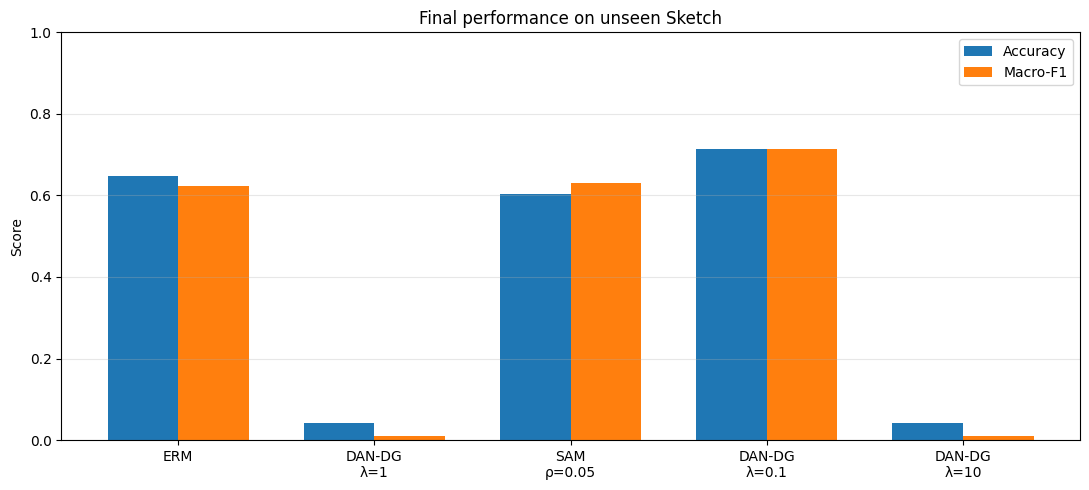

Figure saved to: /content/drive/MyDrive/ATML/PA1-repo/task3/figures/target_sketch_performance.png


In [10]:
plot_order = [
    "erm",
    "dan_dg",
    "sam",
    "dan_dg_lambda_0p1",
    "dan_dg_lambda_10p0",
]

display_names = {
    "erm": "ERM",
    "dan_dg": "DAN-DG\nλ=1",
    "sam": "SAM\nρ=0.05",
    "dan_dg_lambda_0p1": (
        "DAN-DG\nλ=0.1"
    ),
    "dan_dg_lambda_10p0": (
        "DAN-DG\nλ=10"
    ),
}

plot_table = (
    target_summary
    .set_index("method")
    .loc[plot_order]
)

positions = np.arange(
    len(plot_order)
)

bar_width = 0.36

figure, axis = plt.subplots(
    figsize=(11, 5)
)

axis.bar(
    positions - bar_width / 2,
    plot_table[
        "target_accuracy"
    ],
    width=bar_width,
    label="Accuracy",
)

axis.bar(
    positions + bar_width / 2,
    plot_table[
        "target_macro_f1"
    ],
    width=bar_width,
    label="Macro-F1",
)

axis.set_xticks(
    positions
)

axis.set_xticklabels(
    [
        display_names[
            method_name
        ]
        for method_name
        in plot_order
    ]
)

axis.set_ylim(0.0, 1.0)
axis.set_ylabel("Score")
axis.set_title(
    "Final performance on unseen Sketch"
)
axis.grid(
    axis="y",
    alpha=0.3,
)
axis.legend()

figure.tight_layout()

figure_path = (
    TASK3_REPO_ROOT
    / "figures/"
    "target_sketch_performance.png"
)

figure_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

figure.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to:",
    figure_path,
)

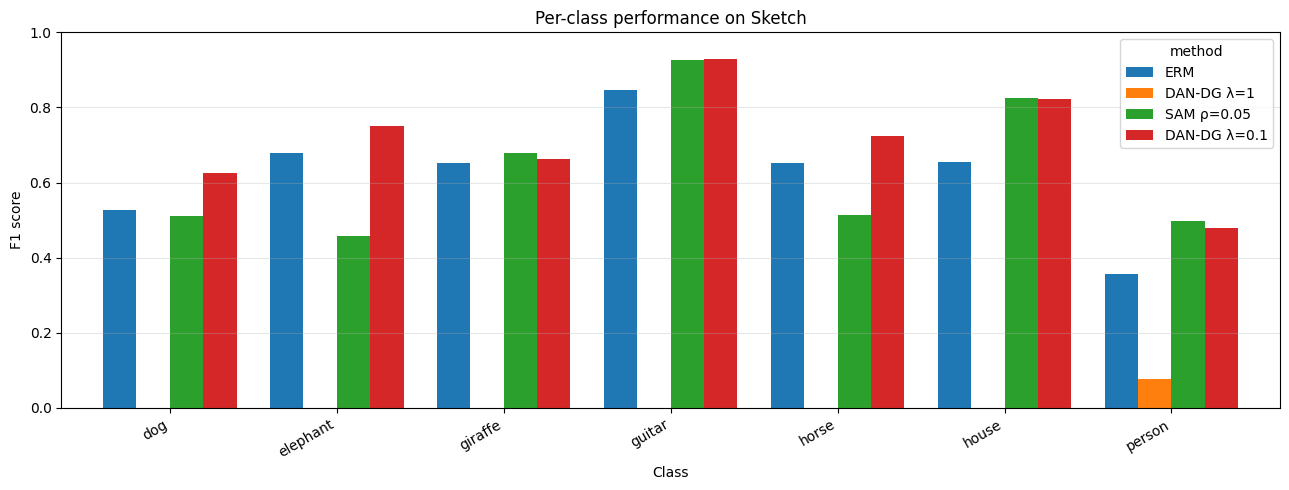

Figure saved to: /content/drive/MyDrive/ATML/PA1-repo/task3/figures/target_sketch_per_class.png


In [11]:
per_class_methods = [
    "erm",
    "dan_dg",
    "sam",
    "dan_dg_lambda_0p1",
]

per_class_display_names = {
    "erm": "ERM",
    "dan_dg": "DAN-DG λ=1",
    "sam": "SAM ρ=0.05",
    "dan_dg_lambda_0p1": (
        "DAN-DG λ=0.1"
    ),
}

per_class_pivot = (
    target_per_class[
        target_per_class[
            "method"
        ].isin(
            per_class_methods
        )
    ]
    .pivot(
        index="class_name",
        columns="method",
        values="f1_score",
    )
    .reindex(
        class_names
    )
    .reindex(
        columns=per_class_methods
    )
)

per_class_pivot = (
    per_class_pivot.rename(
        columns=(
            per_class_display_names
        )
    )
)

axis = per_class_pivot.plot(
    kind="bar",
    figsize=(13, 5),
    width=0.8,
)

axis.set_ylim(0.0, 1.0)
axis.set_xlabel("Class")
axis.set_ylabel("F1 score")
axis.set_title(
    "Per-class performance on Sketch"
)
axis.grid(
    axis="y",
    alpha=0.3,
)

plt.xticks(
    rotation=30,
    ha="right",
)

plt.tight_layout()

figure_path = (
    TASK3_REPO_ROOT
    / "figures/"
    "target_sketch_per_class.png"
)

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to:",
    figure_path,
)

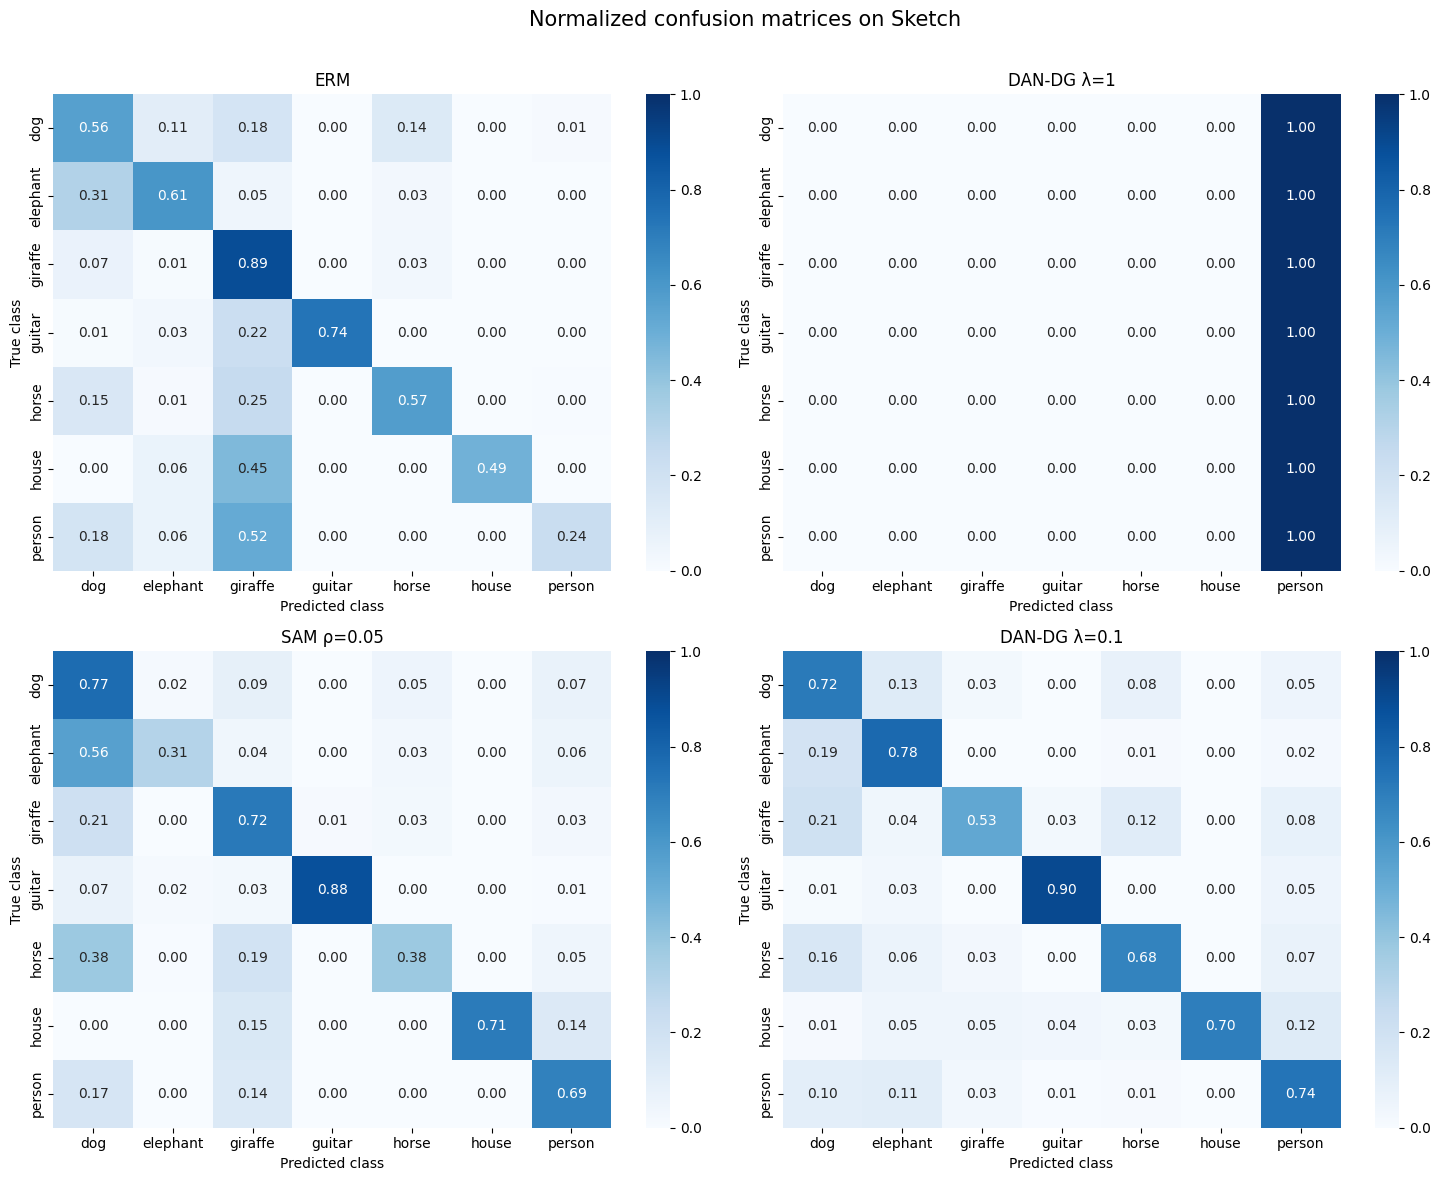

Figure saved to: /content/drive/MyDrive/ATML/PA1-repo/task3/figures/target_sketch_confusion_matrices.png


In [13]:
confusion_methods = [
    "erm",
    "dan_dg",
    "sam",
    "dan_dg_lambda_0p1",
]

confusion_titles = {
    "erm": "ERM",
    "dan_dg": "DAN-DG λ=1",
    "sam": "SAM ρ=0.05",
    "dan_dg_lambda_0p1": (
        "DAN-DG λ=0.1"
    ),
}

figure, axes = plt.subplots(
    2,
    2,
    figsize=(15, 12),
)

for axis, method_name in zip(
    axes.flat,
    confusion_methods,
):
    matrix = target_results[
        method_name
    ]["confusion_matrix"].astype(
        np.float64
    )

    row_totals = matrix.sum(
        axis=1,
        keepdims=True,
    )

    normalized_matrix = np.divide(
        matrix,
        row_totals,
        out=np.zeros_like(
            matrix
        ),
        where=row_totals != 0,
    )

    sns.heatmap(
        normalized_matrix,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0.0,
        vmax=1.0,
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axis,
    )

    axis.set_xlabel(
        "Predicted class"
    )

    axis.set_ylabel(
        "True class"
    )

    axis.set_title(
        confusion_titles[
            method_name
        ]
    )

figure.suptitle(
    "Normalized confusion matrices on Sketch",
    fontsize=15,
)

figure.tight_layout(
    rect=[0, 0, 1, 0.97]
)

figure_path = (
    TASK3_REPO_ROOT
    / "figures/"
    "target_sketch_confusion_matrices.png"
)

figure.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to:",
    figure_path,
)

In [14]:
failure_methods = [
    "erm",
    "dan_dg",
    "sam",
    "dan_dg_lambda_0p1",
]

failure_rows = []

for method_name in failure_methods:
    matrix = target_results[
        method_name
    ]["confusion_matrix"].copy()

    np.fill_diagonal(
        matrix,
        0,
    )

    true_label, predicted_label = (
        np.unravel_index(
            np.argmax(matrix),
            matrix.shape,
        )
    )

    confusion_count = int(
        matrix[
            true_label,
            predicted_label,
        ]
    )

    true_class_total = int(
        target_results[
            method_name
        ]["confusion_matrix"][
            true_label
        ].sum()
    )

    failure_rows.append(
        {
            "method": method_name,
            "true_class": (
                class_names[
                    true_label
                ]
            ),
            "predicted_class": (
                class_names[
                    predicted_label
                ]
            ),
            "confusion_count": (
                confusion_count
            ),
            "true_class_total": (
                true_class_total
            ),
            "confusion_rate": (
                confusion_count
                / true_class_total
            ),
        }
    )

failure_summary = pd.DataFrame(
    failure_rows
)

failure_path = (
    TASK3_REPO_ROOT
    / "results/"
    "target_sketch_failure_summary.csv"
)

failure_summary.to_csv(
    failure_path,
    index=False,
)

print(
    failure_summary.to_string(
        index=False
    )
)

print()
print(
    "Saved to:",
    failure_path,
)

           method true_class predicted_class  confusion_count  true_class_total  confusion_rate
              erm   elephant             dog              233               740        0.314865
           dan_dg      horse          person              816               816        1.000000
              sam   elephant             dog              416               740        0.562162
dan_dg_lambda_0p1    giraffe             dog              155               753        0.205843

Saved to: /content/drive/MyDrive/ATML/PA1-repo/task3/results/target_sketch_failure_summary.csv


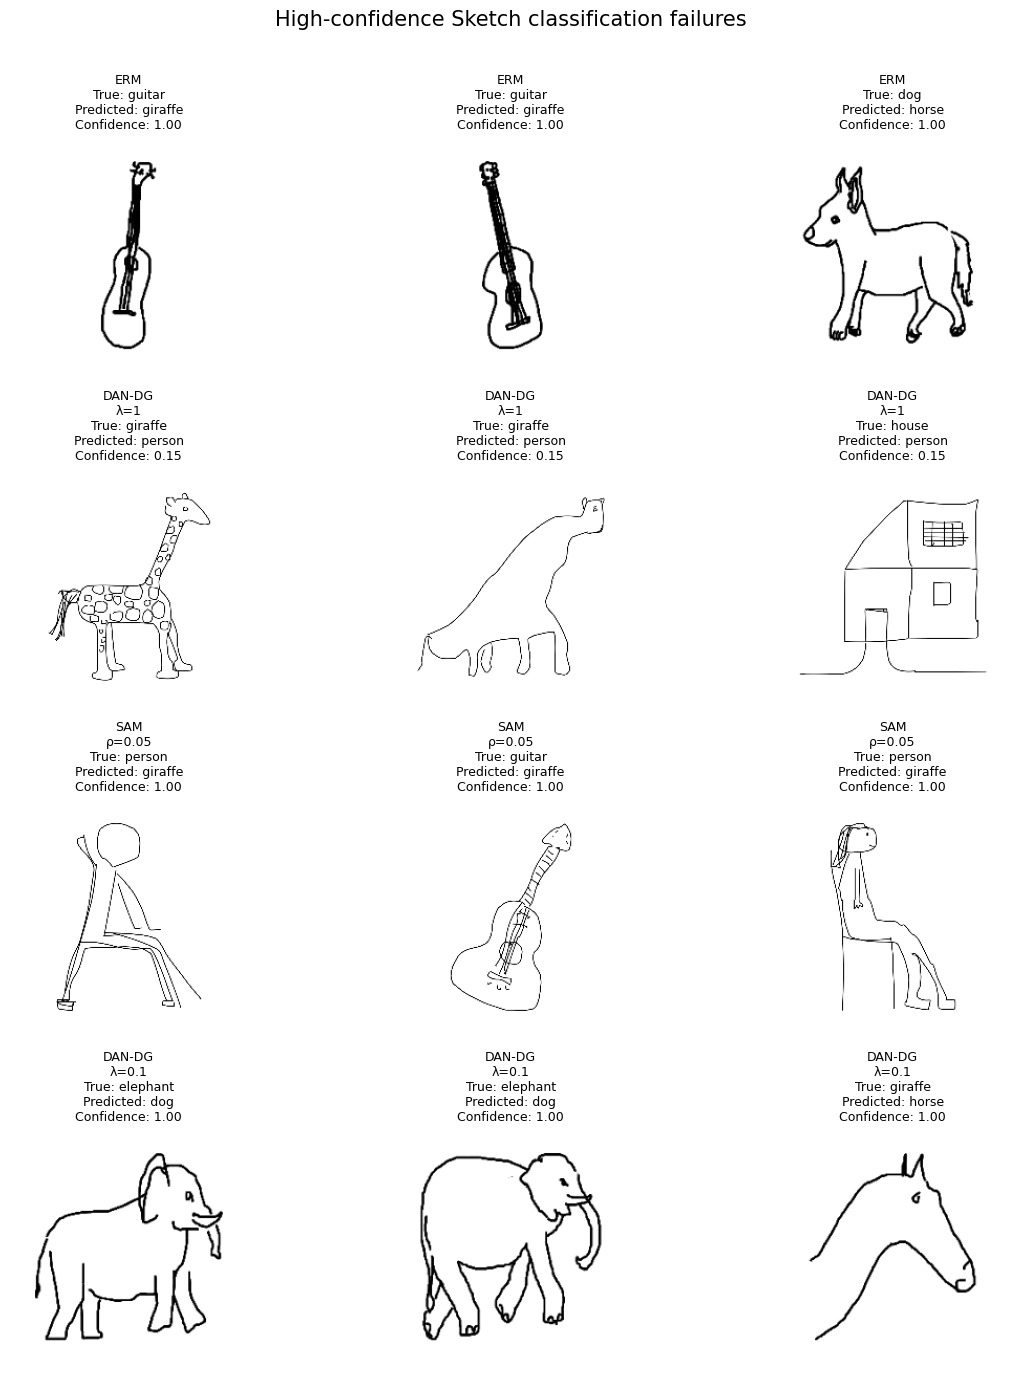

Figure saved to: /content/drive/MyDrive/ATML/PA1-repo/task3/figures/target_sketch_failure_examples.png


In [15]:
examples_per_method = 3

figure, axes = plt.subplots(
    len(failure_methods),
    examples_per_method,
    figsize=(12, 14),
)

for row_index, method_name in enumerate(
    failure_methods
):
    method_failures = (
        target_predictions[
            (
                target_predictions[
                    "method"
                ]
                == method_name
            )
            & (
                ~target_predictions[
                    "correct"
                ]
            )
        ]
        .sort_values(
            "confidence",
            ascending=False,
        )
        .head(
            examples_per_method
        )
        .reset_index(
            drop=True
        )
    )

    for column_index in range(
        examples_per_method
    ):
        axis = axes[
            row_index,
            column_index
        ]

        if column_index >= len(
            method_failures
        ):
            axis.axis("off")
            continue

        failure = method_failures.iloc[
            column_index
        ]

        dataset_index = int(
            failure[
                "dataset_index"
            ]
        )

        image = pacs_dataset[
            dataset_index
        ]["image"]

        axis.imshow(image)

        axis.set_title(
            (
                f"{display_names[method_name]}\n"
                f"True: "
                f"{failure['true_class']}\n"
                f"Predicted: "
                f"{failure['predicted_class']}\n"
                f"Confidence: "
                f"{failure['confidence']:.2f}"
            ),
            fontsize=9,
        )

        axis.axis("off")

figure.suptitle(
    "High-confidence Sketch classification failures",
    fontsize=15,
)

figure.tight_layout(
    rect=[0, 0, 1, 0.97]
)

figure_path = (
    TASK3_REPO_ROOT
    / "figures/"
    "target_sketch_failure_examples.png"
)

figure.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to:",
    figure_path,
)

In [16]:
final_evaluation_metadata = {
    "seed": SEED,
    "target_domain": (
        target_domain
    ),
    "number_of_target_samples": int(
        len(target_dataset)
    ),
    "target_evaluation_timing": (
        "after all training, checkpoint "
        "selection, controlled-study choices, "
        "and source diagnostics were fixed"
    ),
    "main_methods": [
        "erm",
        "dan_dg",
        "sam",
    ],
    "controlled_study_methods": [
        "dan_dg_lambda_0p1",
        "dan_dg_lambda_10p0",
    ],
    "main_dan_dg_weight": 1.0,
    "main_sam_radius": 0.05,
    "checkpoints": (
        checkpoint_information
    ),
    "target_results": [
        {
            "method": row[
                "method"
            ],
            "selected_epoch": int(
                row[
                    "selected_epoch"
                ]
            ),
            "source_selection_macro_f1": float(
                row[
                    "source_selection_macro_f1"
                ]
            ),
            "target_accuracy": float(
                row[
                    "target_accuracy"
                ]
            ),
            "target_macro_f1": float(
                row[
                    "target_macro_f1"
                ]
            ),
            "target_loss": float(
                row[
                    "target_loss"
                ]
            ),
        }
        for _, row
        in target_summary.iterrows()
    ],
    "class_names": (
        class_names
    ),
}

metadata_path = (
    TASK3_REPO_ROOT
    / "results/"
    "final_evaluation_metadata.json"
)

with metadata_path.open(
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        final_evaluation_metadata,
        metadata_file,
        indent=2,
    )

print(
    json.dumps(
        final_evaluation_metadata,
        indent=2,
    )
)

{
  "seed": 6304,
  "target_domain": "sketch",
  "number_of_target_samples": 3929,
  "target_evaluation_timing": "after all training, checkpoint selection, controlled-study choices, and source diagnostics were fixed",
  "main_methods": [
    "erm",
    "dan_dg",
    "sam"
  ],
  "controlled_study_methods": [
    "dan_dg_lambda_0p1",
    "dan_dg_lambda_10p0"
  ],
  "main_dan_dg_weight": 1.0,
  "main_sam_radius": 0.05,
  "checkpoints": {
    "erm": {
      "selected_epoch": 12,
      "source_selection_macro_f1": 0.9366743407680399
    },
    "dan_dg": {
      "selected_epoch": 1,
      "source_selection_macro_f1": 0.05066996495567924
    },
    "sam": {
      "selected_epoch": 11,
      "source_selection_macro_f1": 0.9515140737316559
    },
    "dan_dg_lambda_0p1": {
      "selected_epoch": 13,
      "source_selection_macro_f1": 0.9485386903304263
    },
    "dan_dg_lambda_10p0": {
      "selected_epoch": 2,
      "source_selection_macro_f1": 0.05066996495567924
    }
  },
  "target_resu